In [26]:
# Import required libraries
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
)

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [27]:
# Configuration
DATA_PATH   = "/content/adult.csv.csv"      # ← update if needed
MODEL_PATH  = os.path.join("models", "salary_model.pkl")
OUTPUT_DIR  = "outputs"

os.makedirs("models",    exist_ok=True)
os.makedirs(OUTPUT_DIR,  exist_ok=True)

print("✅ Configuration set:")
print(f"   Data     : {DATA_PATH}")
print(f"   Model    : {MODEL_PATH}")
print(f"   Outputs  : {OUTPUT_DIR}")

✅ Configuration set:
   Data     : /content/adult.csv.csv
   Model    : models/salary_model.pkl
   Outputs  : outputs


In [31]:
# Load & Inspect Data
try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Data loaded  |  shape: {df_raw.shape}")
except FileNotFoundError:
    print(f"❌ File not found: {DATA_PATH}")
    print("   Download from https://archive.ics.uci.edu/ml/datasets/adult")
    raise

SELECTED = [
    "age", "education", "workclass", "marital-status",
    "occupation", "hours-per-week", "capital-gain",
    "capital-loss", "income",
]
df = df_raw[SELECTED].copy()

df.replace(" ?", np.nan, inplace=True)
df.replace("?",  np.nan, inplace=True)

print(f"\n📋 Missing values BEFORE drop:\n{df.isnull().sum()}")
df.dropna(inplace=True)
print(f"\n✅ After dropping missing rows  |  shape: {df.shape}")
print("\nSample data:")
display(df.head())

✅ Data loaded  |  shape: (48842, 15)

📋 Missing values BEFORE drop:
age                  0
education            0
workclass         2799
marital-status       0
occupation        2809
hours-per-week       0
capital-gain         0
capital-loss         0
income               0
dtype: int64

✅ After dropping missing rows  |  shape: (46033, 9)

Sample data:


,age,education,workclass,marital-status,occupation,hours-per-week,capital-gain,capital-loss,income
0,25,11th,Private,Never-married,Machine-op-inspct,40,0,0,<=50K
1,38,HS-grad,Private,Married-civ-spouse,Farming-fishing,50,0,0,<=50K
2,28,Assoc-acdm,Local-gov,Married-civ-spouse,Protective-serv,40,0,0,>50K
3,44,Some-college,Private,Married-civ-spouse,Machine-op-inspct,40,7688,0,>50K
5,34,10th,Private,Never-married,Other-service,30,0,0,<=50K


In [32]:
# Target Distribution
print("🎯 Target Variable Distribution:")
print(df["income"].value_counts())
print("\nPercentage:")
print(df["income"].value_counts(normalize=True).mul(100).round(2))

🎯 Target Variable Distribution:
income
<=50K    34611
>50K     11422
Name: count, dtype: int64

Percentage:
income
<=50K    75.19
>50K     24.81
Name: proportion, dtype: float64


In [33]:
# Feature Engineering

# Education grouping
edu_map = {
    "Preschool": "Other", "1st-4th": "Other", "5th-6th": "Other",
    "7th-8th": "Other",   "9th": "Other",      "10th": "Other",
    "11th": "Other",      "12th": "Other",
    "HS-grad": "HS",
    "Some-college": "Col", "Assoc-voc": "Col", "Assoc-acdm": "Col",
    "Bachelors": "BSc",
    "Masters": "MSc",      "Prof-school": "MSc",
    "Doctorate": "PhD",
}

for col in df.select_dtypes("object").columns:
    df[col] = df[col].str.strip()

df["education"] = df["education"].map(edu_map)
unmapped = df["education"].isna().sum()
if unmapped:
    print(f"⚠️  {unmapped} education values unmapped — filling as 'Other'")
    df["education"].fillna("Other", inplace=True)
else:
    print("✅ Education mapped successfully")
print("\nEducation distribution:\n", df["education"].value_counts())

# Encode target variable (income)
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
print("\n✅ Target encoded  |  0 = <=50K,  1 = >50K")
print(f"   Final shape: {df.shape}")

✅ Education mapped successfully

Education distribution:
 education
HS       14972
Col      13543
BSc       7772
Other     5770
MSc       3400
PhD        576
Name: count, dtype: int64

✅ Target encoded  |  0 = <=50K,  1 = >50K
   Final shape: (46033, 9)


In [34]:
# Train / Test Split
TARGET = "income"
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features     = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features  ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Split complete")
print(f"   Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"   Train class distribution  → 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")

Numeric features  (4): ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
Categorical features (4): ['education', 'workclass', 'marital-status', 'occupation']

✅ Split complete
   Train: 36826 samples  |  Test: 9207 samples
   Train class distribution  → 0: 27688  1: 9138


In [35]:
# Preprocessing Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
], remainder="drop")

print("✅ Preprocessing pipeline created")
print("   Numeric     : Median imputation + StandardScaler")
print("   Categorical : Constant imputation + OneHotEncoder")

✅ Preprocessing pipeline created
   Numeric     : Median imputation + StandardScaler
   Categorical : Constant imputation + OneHotEncoder


In [36]:
# Model Comparison
candidates = {
    "Decision Tree":      DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest":      RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                                  random_state=42, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=42, n_jobs=-1),
}

print("🔵 Training and comparing models...\n")
results = []
for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    pipe.fit(X_train, y_train)
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test,  y_test)
    results.append([name, f"{train_acc:.4f}", f"{test_acc:.4f}"])

print("=" * 55)
print("MODEL COMPARISON RESULTS".center(55))
print("=" * 55)
print(tabulate(results, headers=["Model", "Train Accuracy", "Test Accuracy"], tablefmt="grid"))
print("=" * 55)

🔵 Training and comparing models...

                MODEL COMPARISON RESULTS               
+---------------------+------------------+-----------------+
| Model               |   Train Accuracy |   Test Accuracy |
+=====================+==================+=================+
| Decision Tree       |           0.9418 |          0.8015 |
+---------------------+------------------+-----------------+
| Random Forest       |           0.9509 |          0.8314 |
+---------------------+------------------+-----------------+
| Gradient Boosting   |           0.865  |          0.8616 |
+---------------------+------------------+-----------------+
| Logistic Regression |           0.8069 |          0.807  |
+---------------------+------------------+-----------------+


In [51]:
# Hyperparameter Tuning (Gradient Boosting)
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(random_state=42)),
])

param_grid = {
    "classifier__n_estimators":  [100, 200],
    "classifier__max_depth":     [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample":     [0.8, 1.0],
}

total = 1
for v in param_grid.values():
    total *= len(v)

print(f"🔧 Starting GridSearchCV  |  {total} combinations × 5 folds = {total*5} fits")
print("   Scoring: roc_auc  (robust to class imbalance)\n")

grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("✅ HYPERPARAMETER TUNING COMPLETE".center(60))
print("=" * 60)
print(f"   Best Parameters  : {grid_search.best_params_}")
print(f"   Best CV ROC-AUC  : {grid_search.best_score_:.4f}")
print("=" * 60)

best_model = grid_search.best_estimator_

🔧 Starting GridSearchCV  |  16 combinations × 5 folds = 80 fits
   Scoring: roc_auc  (robust to class imbalance)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

              ✅ HYPERPARAMETER TUNING COMPLETE              
   Best Parameters  : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}
   Best CV ROC-AUC  : 0.9254


In [52]:
# Cross-Validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5,
                             scoring="roc_auc", n_jobs=-1)

print("📊 Cross-Validation Results (ROC-AUC):")
print(f"   Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Folds : {[f'{s:.4f}' for s in cv_scores]}")
print(f"   Min   : {cv_scores.min():.4f}   Max: {cv_scores.max():.4f}")

📊 Cross-Validation Results (ROC-AUC):
   Mean  : 0.9254 ± 0.0013
   Folds : ['0.9252', '0.9245', '0.9238', '0.9277', '0.9258']
   Min   : 0.9238   Max: 0.9277


In [53]:
# Test Set Evaluation
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
test_acc    = best_model.score(X_test, y_test)

print("📋 Test Set Performance:")
print(f"   Accuracy : {test_acc:.4f}\n")
print("Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred,
                             target_names=["<=50K", ">50K"], digits=4))

📋 Test Set Performance:
   Accuracy : 0.8710

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

       <=50K     0.8943    0.9395    0.9163      6923
        >50K     0.7834    0.6633    0.7183      2284

    accuracy                         0.8710      9207
   macro avg     0.8388    0.8014    0.8173      9207
weighted avg     0.8668    0.8710    0.8672      9207



✅ Saved: outputs/confusion_matrix.png


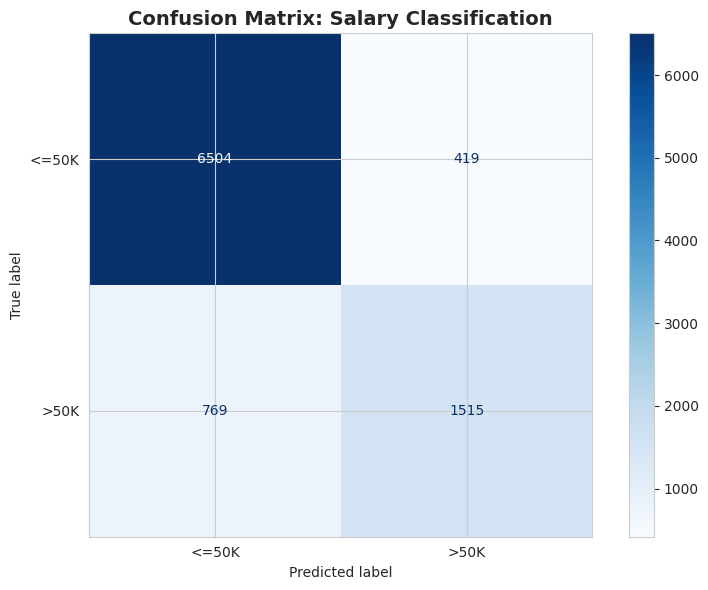

In [54]:
# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["<=50K", ">50K"])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix: Salary Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
print(f"✅ Saved: {OUTPUT_DIR}/confusion_matrix.png")
plt.show()

✅ Saved: outputs/roc_curve.png


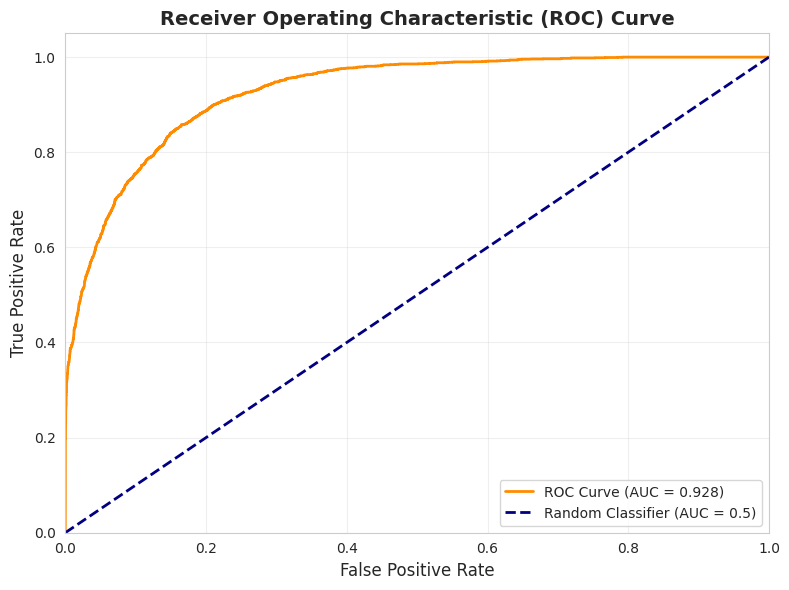

In [55]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc      = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--",
         label="Random Classifier (AUC = 0.5)")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curve",
          fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=300, bbox_inches="tight")
print(f"✅ Saved: {OUTPUT_DIR}/roc_curve.png")
plt.show()

✅ Saved: outputs/feature_importance.png


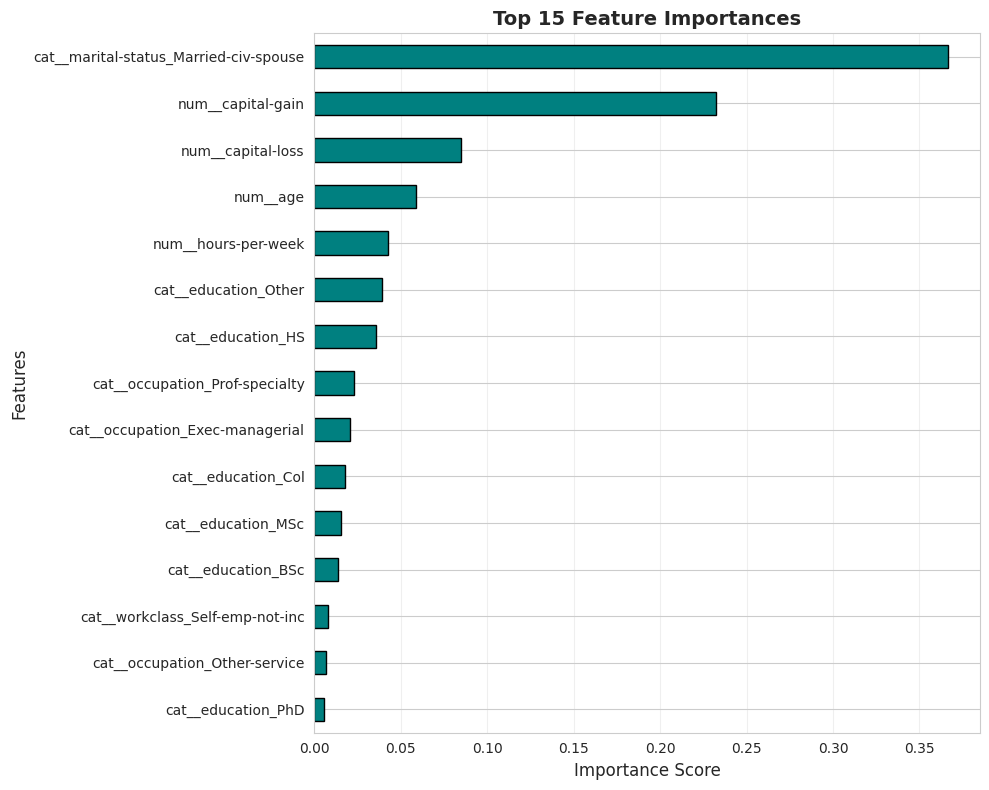

In [56]:
# Feature Importances
classifier     = best_model.named_steps["classifier"]
feature_names  = best_model.named_steps["preprocessor"].get_feature_names_out()
importances    = classifier.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).nlargest(15)

plt.figure(figsize=(10, 8))
feat_imp.sort_values().plot.barh(color="teal", edgecolor="black")
plt.title("Top 15 Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features",         fontsize=12)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=300, bbox_inches="tight")
print(f"✅ Saved: {OUTPUT_DIR}/feature_importance.png")
plt.show()

✅ Saved: outputs/correlation_heatmap.png


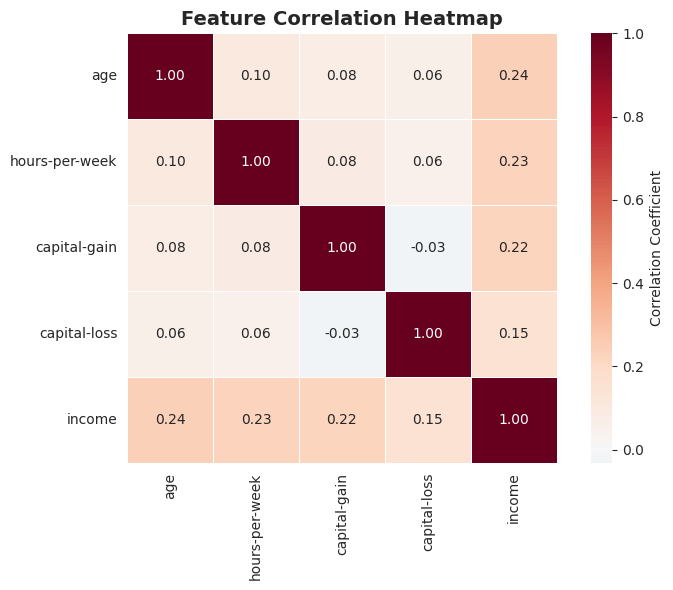

In [57]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", square=True, linewidths=0.5,
            cbar_kws={"label": "Correlation Coefficient"})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_heatmap.png"), dpi=300, bbox_inches="tight")
print(f"✅ Saved: {OUTPUT_DIR}/correlation_heatmap.png")
plt.show()

In [58]:
# Sample Predictions
test_cases = pd.DataFrame([
    [25, "HS",  "Private",       "Never-married",        "Machine-op-inspct", 40,      0,     0],
    [35, "BSc", "Private",       "Married-civ-spouse",   "Exec-managerial",   45,  15024,     0],
    [45, "MSc", "Self-emp-not-inc", "Married-civ-spouse","Prof-specialty",    50,  99999,     0],
    [55, "PhD", "Local-gov",     "Married-civ-spouse",   "Prof-specialty",    60,   7688,     0],
    [30, "Col", "Private",       "Divorced",             "Sales",             38,      0,  1902],
    [50, "BSc", "Federal-gov",   "Married-civ-spouse",   "Tech-support",      40,   3137,     0],
], columns=["age", "education", "workclass", "marital-status",
            "occupation", "hours-per-week", "capital-gain", "capital-loss"])

preds  = best_model.predict(test_cases)
probas = best_model.predict_proba(test_cases)

rows = []
for i, row in test_cases.iterrows():
    label      = ">50K" if preds[i] == 1 else "<=50K"
    confidence = probas[i][preds[i]] * 100
    rows.append([row["age"], row["education"], row["workclass"],
                 row["hours-per-week"], label, f"{confidence:.1f}%"])

print("\n" + "=" * 80)
print("SALARY PREDICTION TEST RESULTS".center(80))
print("=" * 80)
print(tabulate(rows,
               headers=["Age", "Education", "Workclass",
                        "Hrs/Week", "Prediction", "Confidence"],
               tablefmt="grid"))
print("=" * 80)


                         SALARY PREDICTION TEST RESULTS                         
+-------+-------------+------------------+------------+--------------+--------------+
|   Age | Education   | Workclass        |   Hrs/Week | Prediction   | Confidence   |
+=======+=============+==================+============+==============+==============+
|    25 | HS          | Private          |         40 | <=50K        | 99.3%        |
+-------+-------------+------------------+------------+--------------+--------------+
|    35 | BSc         | Private          |         45 | >50K         | 99.6%        |
+-------+-------------+------------------+------------+--------------+--------------+
|    45 | MSc         | Self-emp-not-inc |         50 | >50K         | 99.4%        |
+-------+-------------+------------------+------------+--------------+--------------+
|    55 | PhD         | Local-gov        |         60 | >50K         | 99.1%        |
+-------+-------------+------------------+------------+---

In [59]:
# Save Model
joblib.dump(best_model, MODEL_PATH)
model_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)

print("✅ Model saved successfully!")
print(f"   Location   : {MODEL_PATH}")
print(f"   Model type : {type(best_model.named_steps['classifier']).__name__}")
print(f"   File size  : {model_size:.2f} MB")

✅ Model saved successfully!
   Location   : models/salary_model.pkl
   Model type : GradientBoostingClassifier
   File size  : 0.87 MB


In [60]:
# Load & Verify Saved Model
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame([[40, "BSc", "Private", "Married-civ-spouse",
                         "Exec-managerial", 50, 15024, 0]],
                       columns=["age", "education", "workclass", "marital-status",
                                "occupation", "hours-per-week",
                                "capital-gain", "capital-loss"])

pred  = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0]

print("✅ Model loaded and verified!")
print("\nTest prediction:")
print("   Input  : 40-year-old with Bachelor's, Exec-managerial, 50 hrs/week, cap-gain 15024")
print(f"   Output : {'>50K' if pred == 1 else '<=50K'}")
print(f"   Confidence : {proba[pred]*100:.1f}%")

✅ Model loaded and verified!

Test prediction:
   Input  : 40-year-old with Bachelor's, Exec-managerial, 50 hrs/week, cap-gain 15024
   Output : >50K
   Confidence : 99.6%
